# KPI Analysis – Seller Performance

This notebook analyzes seller performance based on sales, order volume, number of items sold, and customer review scores. The goal is to identify differences in seller performance and explore which sellers contribute most to overall marketplace activity.

In [1]:
import pandas as pd
import sys

print("Python:", sys.version)
print("Pandas:", pd.__version__)

Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Pandas: 2.3.3


In [2]:
from pathlib import Path

data_path = Path("../data")

csv_files = list(data_path.glob("*.csv"))

for file in csv_files:
    print(file.name)

In [3]:
from pathlib import Path
print(Path.cwd())

c:\Users\user777\Desktop\Conclusion Intelegence project\SpikupCapstone2026_CYRV\notebooks


In [4]:
data_path = Path("../data")

print("Data folder exists:", data_path.exists())

for item in data_path.iterdir():
    print(item.name)

Data folder exists: True
cyrv
README.md


In [5]:
data_path = Path("../data/cyrv")

csv_files = list(data_path.glob("*.csv"))

for file in csv_files:
    print(file.name)

CYRV_customers_dataset.csv
CYRV_geolocation_dataset.csv
CYRV_orders_dataset.csv
CYRV_order_items_dataset.csv
CYRV_order_payments_dataset.csv
CYRV_order_reviews_dataset.csv
CYRV_products_dataset.csv
CYRV_sellers_dataset.csv
product_category_name_translation.csv


In [6]:
file_info = []

for file in csv_files:
    file_info.append({
        "file": file.name,
        "size_mb": round(file.stat().st_size / (1024 * 1024), 2)
    })

pd.DataFrame(file_info).sort_values("size_mb", ascending=False)

,file,size_mb
1,CYRV_geolocation_dataset.csv,59.39
2,CYRV_orders_dataset.csv,16.93
3,CYRV_order_items_dataset.csv,14.83
5,CYRV_order_reviews_dataset.csv,13.78
0,CYRV_customers_dataset.csv,8.71
4,CYRV_order_payments_dataset.csv,5.61
6,CYRV_products_dataset.csv,2.30
7,CYRV_sellers_dataset.csv,0.17
8,product_category_name_translation.csv,0.00


In [7]:
customers = pd.read_csv(data_path / "CYRV_customers_dataset.csv")
orders = pd.read_csv(data_path / "CYRV_orders_dataset.csv")
order_items = pd.read_csv(data_path / "CYRV_order_items_dataset.csv")
payments = pd.read_csv(data_path / "CYRV_order_payments_dataset.csv")
reviews = pd.read_csv(data_path / "CYRV_order_reviews_dataset.csv")
products = pd.read_csv(data_path / "CYRV_products_dataset.csv")
sellers = pd.read_csv(data_path / "CYRV_sellers_dataset.csv")
category_translation = pd.read_csv(
    data_path / "product_category_name_translation.csv"
)

print("Datasets loaded successfully ✅")

Datasets loaded successfully ✅


In [8]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [9]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [10]:
print("Order items columns:")
print(order_items.columns.tolist())

print("\nOrders columns:")
print(orders.columns.tolist())

print("\nReviews columns:")
print(reviews.columns.tolist())

print("\nSellers columns:")
print(sellers.columns.tolist())

Order items columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Reviews columns:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Sellers columns:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


In [11]:

# Prepare seller orders using the KPI1 analysis period
valid_orders = orders[
    (orders["order_purchase_timestamp"] >= "2017-01-01") &
    (orders["order_purchase_timestamp"] < "2018-09-01") &
    (~orders["order_status"].isin(["canceled", "unavailable"]))
][["order_id"]].copy()

# Keep order items belonging to valid orders
seller_items = order_items.merge(
    valid_orders,
    on="order_id",
    how="inner"
)

# Calculate seller performance
seller_performance = (
    seller_items.groupby("seller_id")
    .agg(
        total_sales=("price", "sum"),
        number_of_orders=("order_id", "nunique"),
        number_of_items=("order_item_id", "count")
    )
    .reset_index()
)

seller_performance.head()


,seller_id,total_sales,number_of_orders,number_of_items
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3,3
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,200,239
2,002100f778ceb8431b7a1020ff7ab48f,1234.50,51,55
3,003554e2dce176b5555353e4f3555ac8,120.00,1,1
4,004c9cd9d87a3c30c522c48c4fc07416,19712.71,158,170


In [12]:
order_items.merge(
    orders[["order_id", "order_status"]],
    on="order_id",
    how="left"
)["order_status"].value_counts(dropna=False)

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

In [13]:
top_sellers_sales = (
    seller_performance
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_sellers_sales

,seller_id,total_sales,number_of_orders,number_of_items
846,4869f7a5dfa277a7dca6462dcf3b52b2,229237.63,1131,1155
994,53243585a1d6dc2643021fd1853d8905,222776.05,358,410
870,4a3ca9315b744ce9f8e9374361493884,200326.12,1804,1985
2962,fa1c13f2614d7b5c4749cbc52fecda94,192842.13,584,585
1507,7c67e1448b00f6e969d365cea6b010ab,187923.89,982,1364
1532,7e93a43ef30c4f03f38b393420bc753a,171184.88,331,335
2593,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314,1551
1477,7a67c85e85bb2ce8582c35f2203ad736,141715.54,1159,1170
189,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915,1428
1789,955fee9216a65b617aa5c0531780ce60,135159.70,1286,1498


In [14]:
top_sellers_orders = (
    seller_performance
    .sort_values("number_of_orders", ascending=False)
    .head(10)
)

top_sellers_orders

,seller_id,total_sales,number_of_orders,number_of_items
1212,6560211a19b47992c3666cc44a7e94c0,122776.83,1847,2025
870,4a3ca9315b744ce9f8e9374361493884,200326.12,1804,1985
2435,cc419e0650a3c5ba77189a1882b7556a,103634.51,1697,1766
363,1f50f920176fa81dab994f9023523100,106889.31,1403,1930
2593,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314,1551
1789,955fee9216a65b617aa5c0531780ce60,135159.70,1286,1498
1477,7a67c85e85bb2ce8582c35f2203ad736,141715.54,1159,1170
2782,ea8482cd71df3c1969d7b9473ff13abc,37147.53,1145,1202
846,4869f7a5dfa277a7dca6462dcf3b52b2,229237.63,1131,1155
721,3d871de0142ce09b7081e2b9d1733cb1,94508.20,1076,1143


In [15]:
seller_reviews = (
    seller_items[["order_id", "seller_id"]]
    .drop_duplicates()
    .merge(
        reviews[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
)

seller_review_scores = (
    seller_reviews.groupby("seller_id")
    .agg(
        average_review_score=("review_score", "mean"),
        number_of_reviews=("review_score", "count")
    )
    .reset_index()
)

seller_review_scores.head()

,seller_id,average_review_score,number_of_reviews
0,0015a82c2db000af6aaaf3ae2ecb0532,3.666667,3
1,001cca7ae9ae17fb1caed9dfb1094831,3.984772,197
2,002100f778ceb8431b7a1020ff7ab48f,3.903846,52
3,003554e2dce176b5555353e4f3555ac8,5.000000,1
4,004c9cd9d87a3c30c522c48c4fc07416,4.136646,161


In [32]:
print("seller_analysis:", seller_analysis.shape)
print("reliable_sellers:", reliable_sellers.shape)
print("strong_sellers:", strong_sellers.shape)

print("Sales median:", sales_median)
print("Review median:", review_median)

seller_analysis: (3029, 6)
reliable_sellers: (807, 6)
strong_sellers: (201, 6)
Sales median: 6455.4
Review median: 4.161616161616162


In [33]:
print("Sales equal median:",
      (reliable_sellers["total_sales"] == sales_median).sum())

print("Reviews equal median:",
      (reliable_sellers["average_review_score"] == review_median).sum())

print("Strictly above both:",
      ((reliable_sellers["total_sales"] > sales_median) &
       (reliable_sellers["average_review_score"] > review_median)).sum())

Sales equal median: 1
Reviews equal median: 1
Strictly above both: 200


In [16]:
seller_analysis = seller_performance.merge(
    seller_review_scores,
    on="seller_id",
    how="left"
)

seller_analysis.head()

,seller_id,total_sales,number_of_orders,number_of_items,average_review_score,number_of_reviews
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3,3,3.666667,3.0
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,200,239,3.984772,197.0
2,002100f778ceb8431b7a1020ff7ab48f,1234.50,51,55,3.903846,52.0
3,003554e2dce176b5555353e4f3555ac8,120.00,1,1,5.000000,1.0
4,004c9cd9d87a3c30c522c48c4fc07416,19712.71,158,170,4.136646,161.0


In [30]:
print(seller_review_scores.columns.tolist())
print(seller_review_scores.shape)

['seller_id', 'average_review_score', 'number_of_reviews']
(3025, 3)


In [31]:
print(seller_review_scores["seller_id"].duplicated().sum())
print(seller_review_scores["number_of_reviews"].describe())

0
count    3025.000000
mean       32.747438
std       105.876821
min         1.000000
25%         2.000000
50%         7.000000
75%        22.000000
max      1837.000000
Name: number_of_reviews, dtype: float64


In [17]:
seller_analysis.describe()

,total_sales,number_of_orders,number_of_items,average_review_score,number_of_reviews
count,3029.000000,3029.000000,3029.000000,3025.000000,3025.000000
mean,4440.254104,32.764939,36.894024,4.055150,32.747438
std,13983.851012,105.827139,119.989826,0.904491,105.876821
min,3.500000,1.000000,1.000000,1.000000,1.000000
25%,218.700000,2.000000,2.000000,3.837838,2.000000
50%,834.970000,7.000000,8.000000,4.214286,7.000000
75%,3381.730000,22.000000,25.000000,4.639344,22.000000
max,229237.630000,1847.000000,2025.000000,5.000000,1837.000000


In [18]:
reliable_sellers = seller_analysis[
    seller_analysis["number_of_reviews"] >= 20
].copy()

print("Sellers with at least 20 reviews:", len(reliable_sellers))

Sellers with at least 20 reviews: 807


In [19]:
top_rated_sellers = (
    reliable_sellers
    .sort_values(
        ["average_review_score", "number_of_reviews"],
        ascending=[False, False]
    )
    .head(10)
)

top_rated_sellers

,seller_id,total_sales,number_of_orders,number_of_items,average_review_score,number_of_reviews
852,48efc9d94a9834137efd9ea76b065a38,334.70,32,33,5.000000,32.0
775,41c2bad7229b0c25e6becf179ebf63ff,782.00,20,23,4.950000,20.0
33,02f5837340d7eb4f653d676c7256523a,3883.05,30,30,4.833333,30.0
2484,d13e50eaa47b4cbe9eb81465865d8cfc,7155.05,67,69,4.820896,67.0
788,42fa4ee7240e9b8eb4576358ec142ba7,3845.70,22,22,4.809524,21.0
1596,83e197e95a1bbabc8c75e883ed016c47,6574.19,46,54,4.804348,46.0
2579,d9bd94811c3338dceb4181f3dbc0c73e,6911.02,54,61,4.796296,54.0
1487,7ade73f1b9b4e965f9009a4c3a7e2c15,1880.30,27,28,4.769231,26.0
1110,5bffbafbb22daf6d3bfc216a46db8708,5239.70,21,23,4.761905,21.0
643,3785b653b1b82de85ab47dd139938091,1552.00,21,24,4.727273,22.0


In [20]:
top_rated_sellers[
    ["seller_id", "average_review_score", "number_of_reviews"]
]

,seller_id,average_review_score,number_of_reviews
852,48efc9d94a9834137efd9ea76b065a38,5.000000,32.0
775,41c2bad7229b0c25e6becf179ebf63ff,4.950000,20.0
33,02f5837340d7eb4f653d676c7256523a,4.833333,30.0
2484,d13e50eaa47b4cbe9eb81465865d8cfc,4.820896,67.0
788,42fa4ee7240e9b8eb4576358ec142ba7,4.809524,21.0
1596,83e197e95a1bbabc8c75e883ed016c47,4.804348,46.0
2579,d9bd94811c3338dceb4181f3dbc0c73e,4.796296,54.0
1487,7ade73f1b9b4e965f9009a4c3a7e2c15,4.769231,26.0
1110,5bffbafbb22daf6d3bfc216a46db8708,4.761905,21.0
643,3785b653b1b82de85ab47dd139938091,4.727273,22.0


In [21]:
top_sales_reliable = (
    reliable_sellers
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_sales_reliable

,seller_id,total_sales,number_of_orders,number_of_items,average_review_score,number_of_reviews
846,4869f7a5dfa277a7dca6462dcf3b52b2,229237.63,1131,1155,4.136242,1123.0
994,53243585a1d6dc2643021fd1853d8905,222776.05,358,410,4.132022,356.0
870,4a3ca9315b744ce9f8e9374361493884,200326.12,1804,1985,3.828794,1799.0
2962,fa1c13f2614d7b5c4749cbc52fecda94,192842.13,584,585,4.343103,580.0
1507,7c67e1448b00f6e969d365cea6b010ab,187923.89,982,1364,3.488798,982.0
1532,7e93a43ef30c4f03f38b393420bc753a,171184.88,331,335,4.245455,330.0
2593,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314,1551,4.178868,1325.0
1477,7a67c85e85bb2ce8582c35f2203ad736,141715.54,1159,1170,4.245234,1154.0
189,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915,1428,3.989059,914.0
1789,955fee9216a65b617aa5c0531780ce60,135159.70,1286,1498,4.161189,1278.0


In [22]:
seller_correlation = reliable_sellers[
    ["total_sales", "number_of_orders", "average_review_score"]
].corr()

seller_correlation.round(2)

,total_sales,number_of_orders,average_review_score
total_sales,1.00,0.76,-0.04
number_of_orders,0.76,1.00,-0.06
average_review_score,-0.04,-0.06,1.00


In [34]:
seller_correlation.round(4)

,total_sales,number_of_orders,average_review_score
total_sales,1.0000,0.7648,-0.0366
number_of_orders,0.7648,1.0000,-0.0561
average_review_score,-0.0366,-0.0561,1.0000


In [23]:
sales_median = reliable_sellers["total_sales"].median()
review_median = reliable_sellers["average_review_score"].median()

print("Median sales:", round(sales_median, 2))
print("Median review score:", round(review_median, 2))

Median sales: 6455.4
Median review score: 4.16


In [24]:
strong_sellers = reliable_sellers[
    (reliable_sellers["total_sales"] >= sales_median) &
    (reliable_sellers["average_review_score"] >= review_median)
].copy()

print("Strong sellers:", len(strong_sellers))

strong_sellers.sort_values(
    "total_sales", ascending=False
).head(10)

Strong sellers: 201


,seller_id,total_sales,number_of_orders,number_of_items,average_review_score,number_of_reviews
2962,fa1c13f2614d7b5c4749cbc52fecda94,192842.13,584,585,4.343103,580.0
1532,7e93a43ef30c4f03f38b393420bc753a,171184.88,331,335,4.245455,330.0
2593,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314,1551,4.178868,1325.0
1477,7a67c85e85bb2ce8582c35f2203ad736,141715.54,1159,1170,4.245234,1154.0
832,46dc3b2cc0980fb8ec44634e21d2718e,124916.32,509,529,4.220238,504.0
1175,620c87c171fb2a6dd6e8bb4dec959fc6,108771.80,709,765,4.258475,708.0
1919,a1043bafd471dff536d0c462352beb48,101483.16,715,767,4.231417,713.0
721,3d871de0142ce09b7081e2b9d1733cb1,94508.20,1076,1143,4.162289,1066.0
2815,edb1ef5e36e0c8cd84eb3c9b003e486d,79284.55,166,175,4.421687,166.0
2443,ccc4bbb5f32a6ab2b7066a4130f114e3,74004.62,187,192,4.284946,186.0


## Seller Performance – Key Findings

- Seller performance varies substantially across the marketplace, with a relatively small group generating very high sales and order volumes.
- Sales and order volume are strongly related (correlation = 0.76), indicating that higher sales are mainly associated with processing more orders.
- Customer review scores show almost no correlation with sales (-0.03) or order volume (-0.04). High sales therefore do not necessarily imply higher customer satisfaction.
- Among sellers with at least 20 reviews, the median sales value is 6,455.40 and the median review score is 4.15.
- 199 sellers perform above or equal to both median thresholds, combining relatively strong sales performance with strong customer satisfaction.

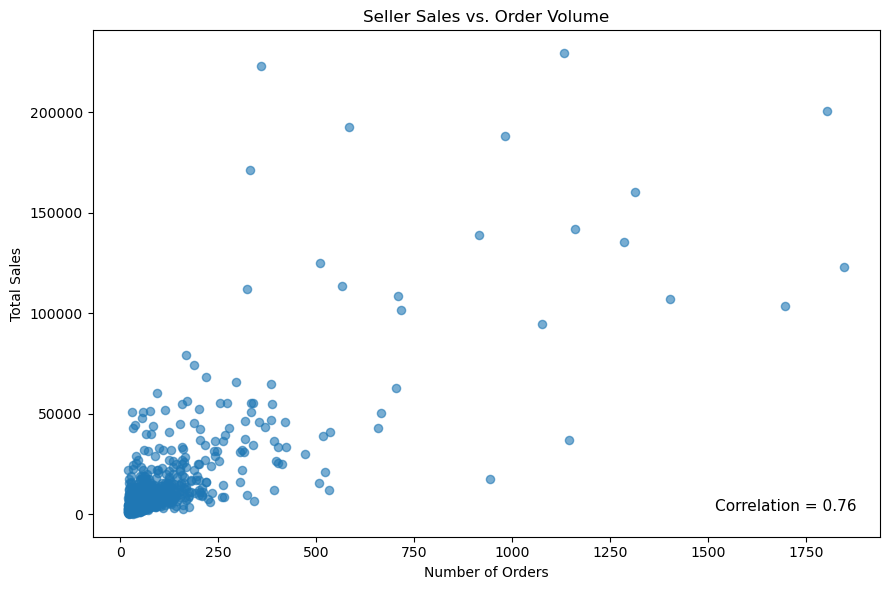

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    reliable_sellers["number_of_orders"],
    reliable_sellers["total_sales"],
    alpha=0.6,
    s=35
)

plt.xlabel("Number of Orders")
plt.ylabel("Total Sales")
plt.title("Seller Sales vs. Order Volume")

plt.text(
    0.97, 0.05,
    "Correlation = 0.76",
    transform=plt.gca().transAxes,
    ha="right",
    fontsize=11
)

plt.tight_layout()
plt.show()

**Insight**

Seller sales and order volume show a strong positive correlation (r = 0.76). Most sellers are concentrated at relatively low sales and order volumes, while a small group generates substantially higher sales. This highlights differences in seller performance across the marketplace.

In [26]:
print(seller_performance.columns.tolist())

['seller_id', 'total_sales', 'number_of_orders', 'number_of_items']


In [27]:
# Reuse the validated seller-level analysis
seller_performance_with_rating = seller_analysis.rename(
    columns={
        "average_review_score": "avg_review_score",
        "number_of_reviews": "review_count"
    }
).copy()

seller_performance_with_rating.head()

,seller_id,total_sales,number_of_orders,number_of_items,avg_review_score,review_count
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3,3,3.666667,3.0
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,200,239,3.984772,197.0
2,002100f778ceb8431b7a1020ff7ab48f,1234.50,51,55,3.903846,52.0
3,003554e2dce176b5555353e4f3555ac8,120.00,1,1,5.000000,1.0
4,004c9cd9d87a3c30c522c48c4fc07416,19712.71,158,170,4.136646,161.0


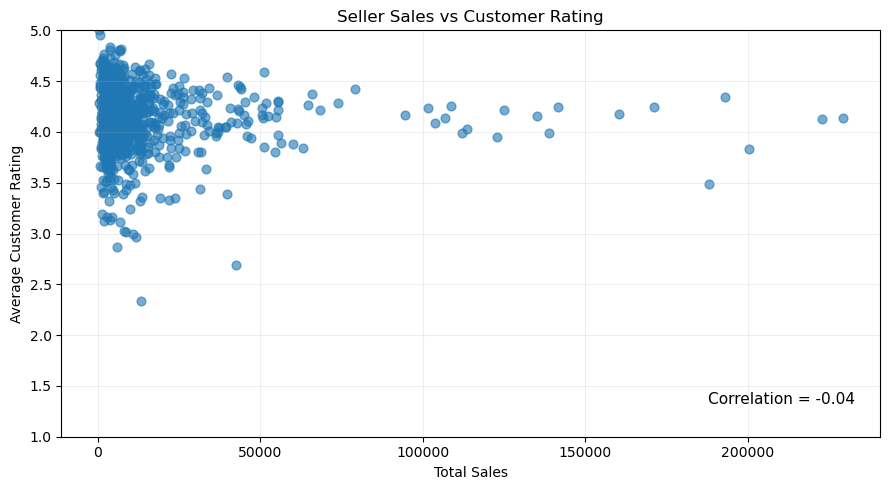

In [28]:
import matplotlib.pyplot as plt

# Keep sellers with at least 20 reviews
seller_rating_plot = seller_performance_with_rating[
    seller_performance_with_rating["review_count"] >= 20
].copy()

# Correlation between sales and customer rating
rating_corr = seller_rating_plot[
    ["total_sales", "avg_review_score"]
].corr().iloc[0, 1]

plt.figure(figsize=(9, 5))

plt.scatter(
    seller_rating_plot["total_sales"],
    seller_rating_plot["avg_review_score"],
    alpha=0.6,
    s=40
)

plt.xlabel("Total Sales")
plt.ylabel("Average Customer Rating")
plt.title("Seller Sales vs Customer Rating")

plt.ylim(1, 5)

plt.text(
    0.97,
    0.08,
    f"Correlation = {rating_corr:.2f}",
    transform=plt.gca().transAxes,
    ha="right",
    fontsize=11
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Insight

- There is almost no relationship between seller sales and customer ratings (correlation = -0.04).
- Higher sales do not necessarily lead to higher customer satisfaction.
- Seller performance should therefore be evaluated using both commercial performance and customer experience.

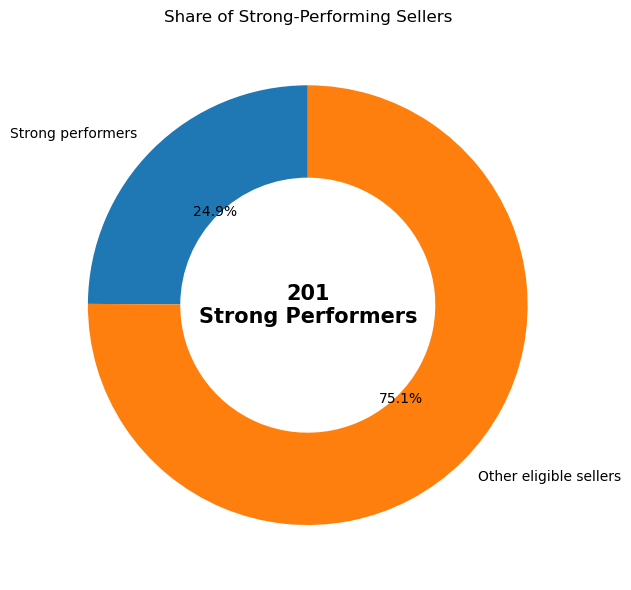

In [29]:
import matplotlib.pyplot as plt

# Use the existing analysis results
strong_count = len(strong_sellers)
other_count = len(reliable_sellers) - strong_count

sizes = [strong_count, other_count]
labels = ["Strong performers", "Other eligible sellers"]

plt.figure(figsize=(8, 6))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.42}
)

plt.text(
    0, 0,
    f"{strong_count}\nStrong Performers",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

plt.title("Share of Strong-Performing Sellers")

plt.tight_layout()
plt.show()

### Insight

- **201 sellers (24.9% of eligible sellers)** achieved both strong sales and strong customer ratings.
- Strong performers were identified among sellers with at least 20 reviews.
- This shows that approximately one-quarter of reliable sellers performed strongly on both commercial performance and customer satisfaction.

### Business Recommendations

- Retain and reward the **201 strong-performing sellers**.
- Support **high-sales sellers with lower ratings** to improve customer experience.
- Increase the visibility of **reliable sellers** to drive more orders and sales.
- Evaluate seller performance using **both sales and customer satisfaction**, rather than sales alone.